<a href="https://colab.research.google.com/github/anjipandey16/IITD/blob/main/Fraud%20Detection%20for%20Digital%20Payment%20Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
input_file = pd.read_csv("/content/sample_data/SynthBank-Fraud v1.0.csv")
input_file.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   txn_id             10000 non-null  int64  
 1   timestamp          10000 non-null  object 
 2   user_id            10000 non-null  int64  
 3   amount             10000 non-null  float64
 4   merchant_category  10000 non-null  object 
 5   channel            10000 non-null  object 
 6   is_fraud           10000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 547.0+ KB


In [ ]:
input_file.head()

,txn_id,timestamp,user_id,amount,merchant_category,channel,is_fraud
0,1,2023-01-01 09:05:00,183,18.91,Restaurants,UPI,0
1,2,2023-01-01 09:15:00,220,33.49,Utility Bills,Credit Card,0
2,3,2023-01-01 09:15:00,460,18.82,Medical,UPI,0
3,4,2023-01-01 09:27:00,256,38.09,Electronics,UPI,0
4,5,2023-01-01 09:28:00,102,45.11,Fashion,NetBanking,0


In [23]:
input_file['timestamp']=pd.to_datetime(input_file['timestamp'])
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
input_file['merchant_category'] = le.fit_transform(input_file['merchant_category'])
input_file['channel'] = le.fit_transform(input_file['channel'])
transaction_date = input_file['timestamp'].dt.month
input_file['t_day'] = input_file['timestamp'].dt.day
input_file['t_month'] = input_file['timestamp'].dt.month
input_file['t_year'] = input_file['timestamp'].dt.year
input_file['t_time'] = input_file['timestamp'].dt.time
input_file.head()


,txn_id,timestamp,user_id,amount,merchant_category,channel,is_fraud,t_day,t_month,t_year,t_time
0,1,2023-01-01 09:05:00,183,18.91,5,3,0,1,1,2023,09:05:00
1,2,2023-01-01 09:15:00,220,33.49,7,0,0,1,1,2023,09:15:00
2,3,2023-01-01 09:15:00,460,18.82,4,3,0,1,1,2023,09:15:00
3,4,2023-01-01 09:27:00,256,38.09,0,3,0,1,1,2023,09:27:00
4,5,2023-01-01 09:28:00,102,45.11,1,2,0,1,1,2023,09:28:00


In [ ]:
data = (input_file['txn_id'],input_file['user_id'],input_file['amount'],input_file['merchant_category'],input_file['channel'],input_file['t_day'])
heat_map = sns.heatmap(data=data,annot=True)
plt.show()

In [ ]:
input_file.isna().count()

,0
txn_id,10000
timestamp,10000
user_id,10000
amount,10000
merchant_category,10000
channel,10000
is_fraud,10000


In [ ]:
input_file.isnull().count()

,0
txn_id,10000
timestamp,10000
user_id,10000
amount,10000
merchant_category,10000
channel,10000
is_fraud,10000


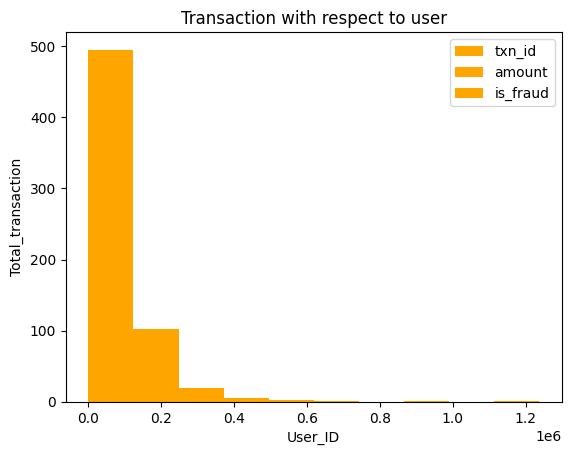

In [5]:

input_file.groupby("user_id").sum().plot(kind='hist',color='orange')
plt.title("Transaction with respect to user")
plt.xlabel("User_ID")
plt.ylabel("Total_transaction")
plt.show()

In [14]:
input_file.head()

,txn_id,timestamp,user_id,amount,merchant_category,channel,is_fraud
0,1,2023-01-01 09:05:00,183,18.91,5,3,0
1,2,2023-01-01 09:15:00,220,33.49,7,0,0
2,3,2023-01-01 09:15:00,460,18.82,4,3,0
3,4,2023-01-01 09:27:00,256,38.09,0,3,0
4,5,2023-01-01 09:28:00,102,45.11,1,2,0


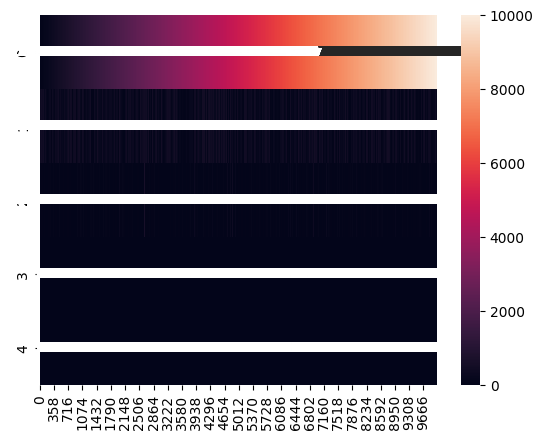

In [17]:
data = (input_file['txn_id'],input_file['user_id'],input_file['amount'],input_file['merchant_category'],input_file['channel'])
heat_map = sns.heatmap(data=data,annot=True)
plt.show()